In [5]:
%pip install kagglehub
import kagglehub

# Download latest version
path = kagglehub.dataset_download("asaniczka/uk-optimal-product-price-prediction")

print("Path to dataset files:", path)

Note: you may need to restart the kernel to use updated packages.
Path to dataset files: C:\Users\gkahl\.cache\kagglehub\datasets\asaniczka\uk-optimal-product-price-prediction\versions\3


In [6]:
import pandas as pd

In [8]:
import os
file_path = os.path.join(path, "amz_uk_price_prediction_dataset.csv")
df = pd.read_csv(file_path)

### Part 1: Understanding Product Categories

**Business Question**: What are the most popular product categories on Amazon UK, and how do they compare in terms of listing frequency?

1. **Frequency Tables**:
    - Generate a frequency table for the product `category`.
    - Which are the top 5 most listed product categories?

2. **Visualizations**:
    - Display the distribution of products across different categories using a bar chart. *If you face problems understanding the chart, do it for a subset of top categories.*
    - For a subset of top categories, visualize their proportions using a pie chart. Does any category dominate the listings?

In [39]:
print(df.shape)
relfreqtable_category = df["category"].value_counts(normalize=True).round(5)
absfreqtable_category = df["category"].value_counts().round(4)
freqtables = pd.concat([absfreqtable_category, relfreqtable_category], axis=1)
freqtables.columns = ['absolute_frequency', 'relative_frequency']
top_categories = df["category"].value_counts(normalize=True).head(5)
print(top_categories)
relfreqtable_category
# The top 5 most listed product categories are:
# Sports & Outdoors / Beauty / Handmade Clothing, Shoes & Accessories / Bath & Body / Birthday Gifts

(2443651, 9)
category
Sports & Outdoors                         0.342219
Beauty                                    0.007903
Handmade Clothing, Shoes & Accessories    0.007869
Bath & Body                               0.007813
Birthday Gifts                            0.007766
Name: proportion, dtype: float64


category
Sports & Outdoors                         0.34222
Beauty                                    0.00790
Handmade Clothing, Shoes & Accessories    0.00787
Bath & Body                               0.00781
Birthday Gifts                            0.00777
                                           ...   
Alexa Built-In Devices                    0.00004
Motorbike Chassis                         0.00004
Plugs                                     0.00004
Smart Home Security & Lighting            0.00004
Smart Speakers                            0.00002
Name: proportion, Length: 296, dtype: float64

In [22]:
import matplotlib.pyplot as plt # viz
import seaborn as sns # better viz
import numpy as np # numerical python

%matplotlib inline

In [40]:
top_categories

category
Sports & Outdoors                         0.342219
Beauty                                    0.007903
Handmade Clothing, Shoes & Accessories    0.007869
Bath & Body                               0.007813
Birthday Gifts                            0.007766
Name: proportion, dtype: float64

C:\Users\gkahl\AppData\Local\Temp\ipykernel_6048\2972997551.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


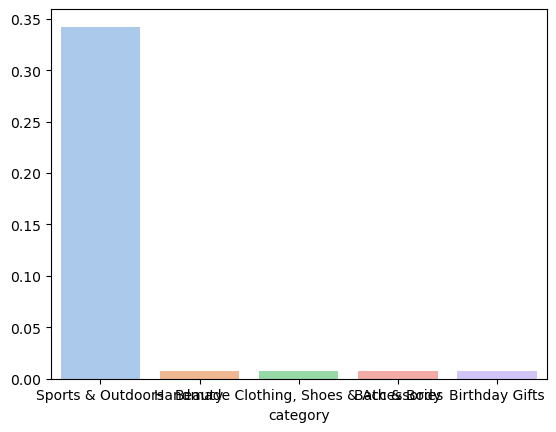

In [42]:
sns.barplot(
    x=top_categories.index,
    y=top_categories.values,
    palette="pastel",
    #legend=True,
)
plt.show()

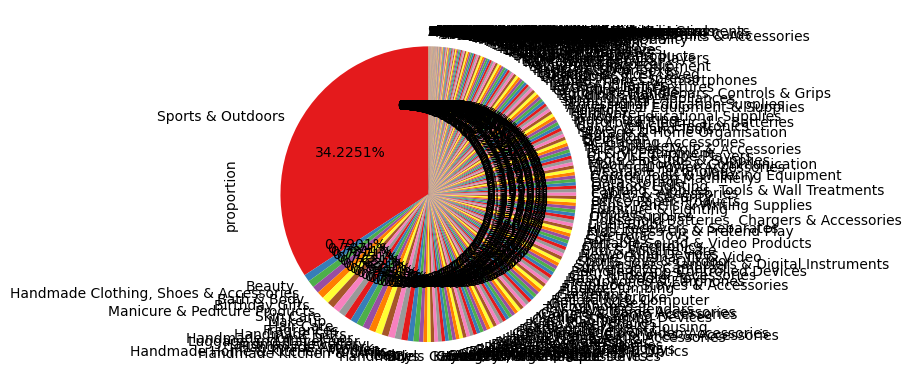

In [44]:
relfreqtable_category.plot.pie(autopct='%1.4f%%' ,startangle=90, colors=sns.color_palette('Set1'))
plt.show()

The top 5 most listed product categories are:
- Sports & Outdoors 
- Beauty
- Handmade Clothing, Shoes & Accessories
- Bath & Body
- Birthday Gifts

Barplot only makes sense if one looks at the top 5 categories.
Pie Chart is visually interesting but impossible to read.
Category "Sports & Outdoors" dominates all others.


### Part 2: Delving into Product Pricing

**Business Question**: How are products priced on Amazon UK, and are there specific price points or ranges that are more common?

1. **Measures of Centrality**:
    - Calculate the mean, median, and mode for the `price` of products.
    - What's the average price point of products listed? How does this compare with the most common price point (mode)?

2. **Measures of Dispersion**:
    - Determine the variance, standard deviation, range, and interquartile range for product `price`.
    - How varied are the product prices? Are there any indicators of a significant spread in prices?

3. **Visualizations**:
    - Is there a specific price range where most products fall? Plot a histogram to visualize the distribution of product prices. *If its hard to read these diagrams, think why this is, and explain how it could be solved.*.
    - Are there products that are priced significantly higher than the rest? Use a box plot to showcase the spread and potential outliers in product pricing. 

In [ ]:
print("The mean price of products is ",df["price"].mean())
print("The median price of products is ",df["price"].median())
print("The most common price of products is ",df["price"].mode()[0]) # Only displaying the first mode (0) after checking that it is unique, in order to avoid printing index 0.

The mean price of products is  89.24380943923661
The median price of products is  19.09
The most common price of products is  9.99


Mean price of 89 is far higher than modal price of 9.99. This means that while 9.99 is the most common individual price, the actual mass focus of the distribution is much higher. Seeing that half of all items cost 19 or lower (median), this means that we can expect some outliers among prices which drive the average up.

In [52]:
print("The variance within product prices is ",df["price"].var())
print("The standard deviation within product prices is ",df["price"].std())
print("The range of product prices is ",(df["price"].max()-df["price"].min()))
print("The interquartile range of product prices is",(df["price"].quantile(0.75)-df["price"].quantile(0.25)))
df["price"].describe()

The variance within product prices is  119445.48532256528
The standard deviation within product prices is  345.60886175352226
The range of product prices is  100000.0
The interquartile range of product prices is 36.0


count    2.443651e+06
mean     8.924381e+01
std      3.456089e+02
min      0.000000e+00
25%      9.990000e+00
50%      1.909000e+01
75%      4.599000e+01
max      1.000000e+05
Name: price, dtype: float64

The range of product prices is extremely high with 100.000 (keeping in mind that average price is 89), which indicates a massive spread. Standard deviation is also very high (345.6) which means that on average we can expect an item's price to diverge 346 monetary units from the average.

The 99%-Quantile of prices is:  1408.82  (meaning 99% of all items don't cross this threshold)
The 95%-Quantile of prices is:  349.5  (meaning 95% of all items don't cross this threshold)


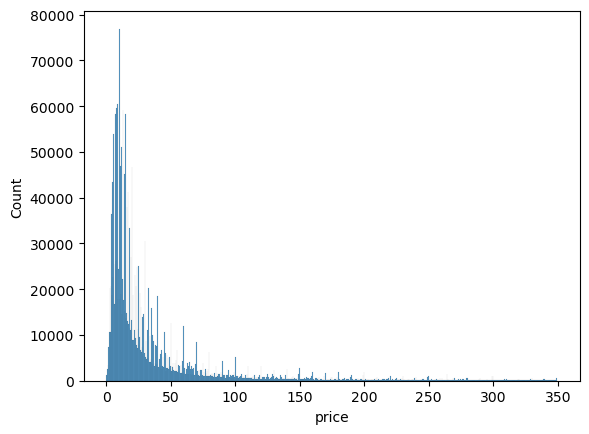

In [57]:
# Calculate .99 quantile:
q99 = df.price.quantile(0.99)
print("The 99%-Quantile of prices is: ",q99," (meaning 99% of all items don't cross this threshold)")
# Calculate .95 quantile:
q95 = df.price.quantile(0.95)
print("The 95%-Quantile of prices is: ",q95," (meaning 95% of all items don't cross this threshold)")
# Only display data up to q95:
sns.histplot(df[df.price <= q95]["price"], bins="auto")
plt.show()

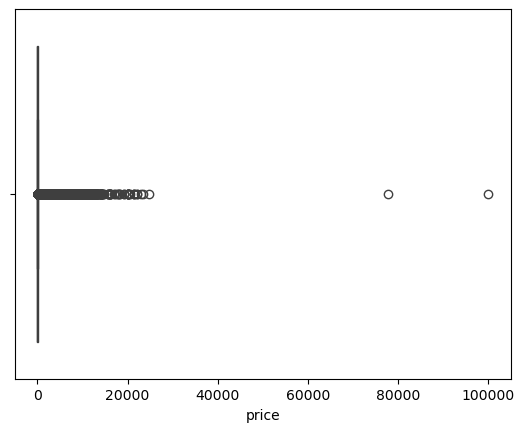

In [58]:
sns.boxplot(x=df.price)
plt.show()

A few items have extremely high prices, which pulls average, spread, max, std etc. massively upwards. 
If we filter using the 95%-quantile, visualization gets better. One could also consider clustering items into different categories based on their price.
The Boxplot shows that the overwhelming majority of items does not go beyond 30000.

### Part 3: Unpacking Product Ratings

**Business Question**: How do customers rate products on Amazon UK, and are there any patterns or tendencies in the ratings?

1. **Measures of Centrality**:
    - Calculate the mean, median, and mode for the `rating` of products.
    - How do customers generally rate products? Is there a common trend?

2. **Measures of Dispersion**:
    - Determine the variance, standard deviation, and interquartile range for product `rating`.
    - Are the ratings consistent, or is there a wide variation in customer feedback?

3. **Shape of the Distribution**:
    - Calculate the skewness and kurtosis for the `rating` column. 
    - Are the ratings normally distributed, or do they lean towards higher or lower values?

4. **Visualizations**:
    - Plot a histogram to visualize the distribution of product ratings. Is there a specific rating that is more common?

In [70]:
print("The mean rating of a product is ",df.stars.mean())
print("The median rating of a product is ",df.stars.median())
print("The most frequent rating of a product is ",df.stars.mode())
print("The variance within product ratings is ",df.stars.var())
print("The standard deviation within product ratings is ",df.stars.std())
print("The interquartile range of product ratings is",(df.stars.quantile(0.75)-df.stars.quantile(0.25)))
print("The range of product ratings is ",(df.stars.max()-df.stars.min()))

# Let's take a closer look at the quantiles:
print("0.75 quantile:",df.stars.quantile(0.75))
print("0.90 quantile:",df.stars.quantile(0.90))
print("0.95 quantile:",df.stars.quantile(0.95))
print("0.99 quantile:",df.stars.quantile(0.99))

The mean rating of a product is  2.152836472966066
The median rating of a product is  0.0
The most frequent rating of a product is  0    0.0
Name: stars, dtype: float64
The variance within product ratings is  4.81743402976196
The standard deviation within product ratings is  2.1948653785054697
The interquartile range of product ratings is 4.4
The range of product ratings is  5.0
0.75 quantile: 4.4
0.90 quantile: 4.7
0.95 quantile: 5.0
0.99 quantile: 5.0


Ratings range from 0 to 5. Assuming that the options range from 0 to 5, this means that customer satisfaction has maximum range.
Most frequently, customers have chosen 0 stars, which is a horrible rating. Median rating is 0, which means that half of all ratings are 0!
The mean rating is also rather low at 2.15, with even higher standard deviation. The interquartile range covers almost the entire range, which means that values are not concentrated much around the center of the interval. The upper 25% lie close to 5 (0.75-Quantile 4.4). 
Together with median=0 and high upper quantiles this points to a possible bimodal distribution.

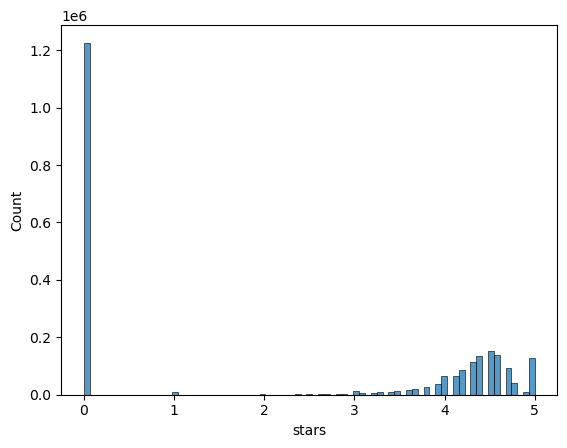

In [ ]:
sns.histplot(df.stars, bins="auto")
plt.show()
# As mentioned, Rating 0 (lowest) is extremely common.

Explainer